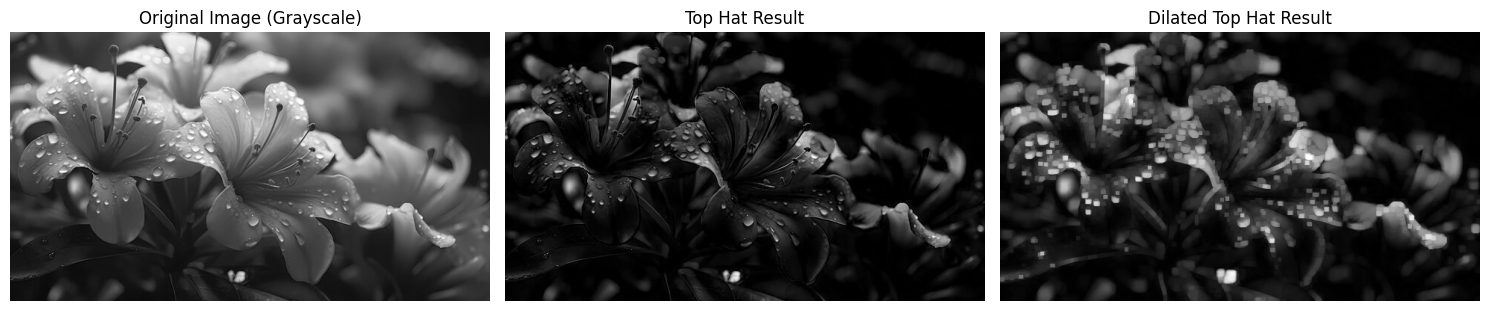

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the uploaded image
image_path = '/content/Flower.jpg'
image = cv2.imread(image_path) # Load the image

# Check if image was loaded successfully
if image is None:
    raise FileNotFoundError(f"Error: Image not found at {image_path}")

# Convert image to grayscale for morphological operations
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# 2. Define a structuring element (kernel)
#    The size and shape of the kernel depend on the features you want to extract.
#    A larger kernel will highlight larger features.
kernel_size = (30, 30)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, kernel_size)

# 3. Apply the Top Hat operation
#    Top Hat is the difference between the original image and its opening.
#    It highlights bright regions on a dark background.
tophat_image = cv2.morphologyEx(image_gray, cv2.MORPH_TOPHAT, kernel)

# 4. Dilate the foreground regions (output of Top Hat)
#    This will expand the bright regions found by the Top Hat operation.
dilation_kernel_size = (5, 5) # Smaller kernel for dilation
dilation_kernel = np.ones(dilation_kernel_size, np.uint8)
dilated_tophat = cv2.dilate(tophat_image, dilation_kernel, iterations=1)

# 5. Display the results
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image_gray, cmap='gray') # Display grayscale original
plt.title('Original Image (Grayscale)')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(tophat_image, cmap='gray')
plt.title('Top Hat Result')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(dilated_tophat, cmap='gray')
plt.title('Dilated Top Hat Result')
plt.axis('off')

plt.tight_layout()
plt.show()

### Explanation:

1.  **Synthetic Image Creation**: We start by creating a simple grayscale image with a dark background and a few bright circular regions to simulate foreground objects, along with some noise.
2.  **Structuring Element (Kernel)**: A structuring element (or kernel) defines the neighborhood for the morphological operation. Its size and shape are crucial. Here, an elliptical kernel of size `(30, 30)` is used.
3.  **Top Hat Operation (`cv2.MORPH_TOPHAT`)**: This operation calculates the difference between the original image and its morphological opening. Opening is erosion followed by dilation. The Top Hat operation effectively highlights small, bright objects or features on a darker background that are smaller than the structuring element. It removes the background variations and leaves only the bright components.
4.  **Dilation on Top Hat Result**: After obtaining the bright foreground regions using Top Hat, we apply a standard dilation operation (`cv2.dilate`) to the `tophat_image`. Dilation expands the bright (white) regions. This step directly addresses your request to "dilate the foreground regions" after they have been isolated/enhanced by the Top Hat technique.